In [1]:
import anndata as ad
import scanpy as sc

In [66]:
lung = ad.read_h5ad('/t9k/mnt/zsk/workspace/HEST/project/data_process/single_cell_annotation/temporary_data/10x_lung_st.h5ad')

/t9k/mnt/.conda/envs/HEST1/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [67]:
lung.obs['barcode'] = lung.obs['sample'].astype(str)+'_'+lung.obs.index.astype(str)

In [68]:
lung.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,sample,pxl_row_in_fullres_old,pxl_col_in_fullres_old,barcode
AACAATCCGAGTGGAC-1,1,103,47,1124.0,9810.0,11981,9.391161,115467.0,11.656749,28.299861,31.936397,36.186963,44.106108,7015.0,8.855948,6.075329,TENX72,NaN,NaN,TENX72_AACAATCCGAGTGGAC-1
AACAATGGAACCACAT-1,1,54,32,16580.0,6928.0,9371,9.145482,47607.0,10.770756,28.888609,32.291470,36.650072,44.913563,3559.0,8.177516,7.475791,TENX72,NaN,NaN,TENX72_AACAATGGAACCACAT-1
AACACCAGCCTACTCG-1,1,31,39,23862.0,8140.0,9567,9.166179,60219.0,11.005760,29.963965,33.658812,38.069380,46.566698,4265.0,8.358432,7.082482,TENX72,NaN,NaN,TENX72_AACACCAGCCTACTCG-1
AACACCATTCGCATAC-1,1,53,139,17078.0,26469.0,11195,9.323312,101700.0,11.529793,31.485742,35.090462,39.164208,46.945919,8782.0,9.080573,8.635201,TENX72,NaN,NaN,TENX72_AACACCATTCGCATAC-1
AACACCGAGCTTGGAT-1,1,56,24,15935.0,5473.0,9977,9.208138,62929.0,11.049778,28.956443,32.530312,36.827218,45.049182,4921.0,8.501471,7.819924,TENX72,NaN,NaN,TENX72_AACACCGAGCTTGGAT-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTGGTATAGGTATG-1,1,24,126,6667.0,23169.0,588,6.378426,846.0,6.741701,32.151300,42.316785,54.137116,89.598109,0.0,0.000000,0.000000,MISC13,NaN,NaN,MISC13_TTGTGGTATAGGTATG-1
TTGTTCAGTGTGCTAC-1,1,24,64,6658.0,16359.0,4107,8.320692,12286.0,9.416297,40.582777,44.888491,50.154648,60.035813,0.0,0.000000,0.000000,MISC13,NaN,NaN,MISC13_TTGTTCAGTGTGCTAC-1
TTGTTGTGTGTCAAGA-1,1,31,77,7998.0,17785.0,358,5.883322,585.0,6.373320,47.350427,55.897436,72.991453,100.000000,0.0,0.000000,0.000000,MISC13,NaN,NaN,MISC13_TTGTTGTGTGTCAAGA-1
TTGTTTCATTAGTCTA-1,1,60,30,13534.0,12616.0,252,5.533389,307.0,5.730100,34.201954,50.488599,83.061889,100.000000,0.0,0.000000,0.000000,MISC13,NaN,NaN,MISC13_TTGTTTCATTAGTCTA-1


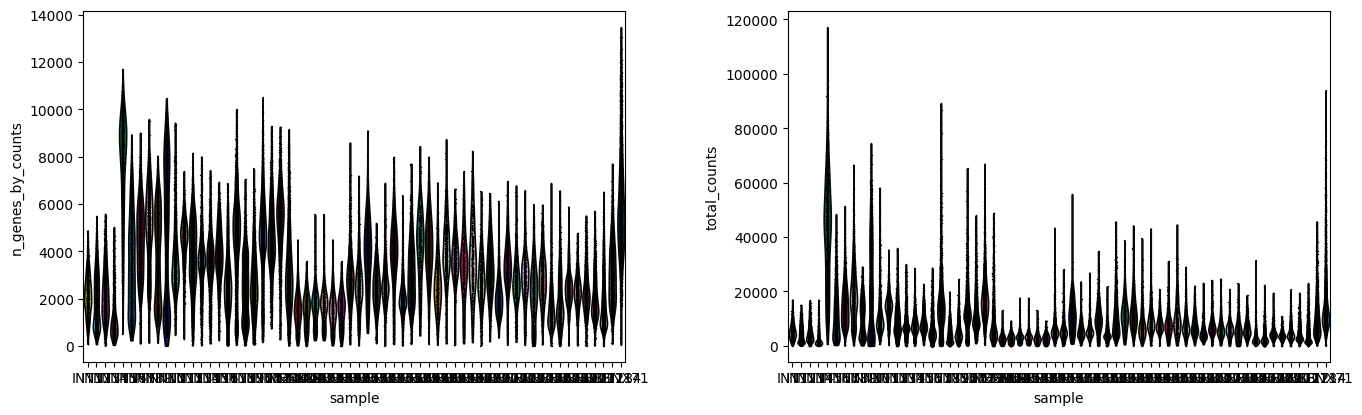

In [50]:
sc.pl.violin(lung,['n_genes_by_counts','total_counts'],groupby='sample')

In [69]:
flitered = lung.obs[(lung.obs['n_genes_by_counts'] < 1000) | (lung.obs['total_counts'] < 2000)]

In [70]:
flitered_index = flitered['barcode'].to_list()

In [71]:
len(flitered_index)

36726

In [17]:
import h5py

In [72]:
with h5py.File('/t9k/mnt/zsk/workspace/HEST/dataset/train_data/lung.h5', 'r') as f:
    existing_groups = list(f.keys())
# 筛选出实际存在的group
groups_to_delete = [name for name in flitered_index if name in existing_groups]
if not groups_to_delete:
    print("没有找到要删除的groups")

In [73]:
len(existing_groups)

10072

In [74]:
len(groups_to_delete)

145

In [75]:
# 删除groups
with h5py.File('/t9k/mnt/zsk/workspace/HEST/dataset/train_data/lung.h5', 'a') as f:  # 'a'模式表示读写
    for group_name in groups_to_delete:
        del f[group_name]
    print("finish")

finish
